In [1]:
# !uv run python -m ensurepip --upgrade
# !python -m spacy download en_core_web_sm

In [2]:
import json
import os
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from scipy import stats
from sklearn.preprocessing import OneHotEncoder

from mllm_shap.connectors.enums import Role

nlp = spacy.load("en_core_web_sm")

sns.set_style("whitegrid")


EXPERIMENTS_DIR: str = os.path.abspath(os.path.join(".", "..", "experiments_output"))
SINGLE_SENTENCE_EXPERIMENTS_DIR: str = os.path.join(EXPERIMENTS_DIR, "single_sentence_2025_02_12")

CASES: dict[str, str] = {
    "T2T": "text_text_limited_neyman_lin3_0",
    "SM2T": "audio_male_text_limited_neyman_lin3_0",
    "SM2S": "audio_male_audio_limited_neyman_lin3_0",
    "SF2T": "audio_female_text_limited_neyman_lin3_0",
    "SF2S": "audio_female_audio_limited_neyman_lin3_0",
}

/Users/pawelp/Desktop/education/pw/bachelor/MLLM-Shap-2/MLLM-Shap/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
def load_experiments_results(case: str) -> pd.DataFrame:
    """Load experiment results for a given case."""
    case_dir = os.path.join(SINGLE_SENTENCE_EXPERIMENTS_DIR, CASES[case])
    samples_dir = os.path.join(case_dir, "samples")
    all_files = [os.path.join(samples_dir, f) for f in os.listdir(samples_dir) if f.endswith(".json")]

    dts = []
    for f in all_files:
        with open(f, "r", encoding="utf-8") as file:
            dts.append(json.load(file))

    experiments_df = pd.DataFrame(dts)

    experiments_test_df = experiments_df.copy()

    experiments_test_df["n_turns"] = experiments_test_df["conversation"].apply(len)
    experiments_test_df["raw_system_prompt"] = experiments_test_df["conversation"].apply(
        lambda x: "".join(x[0][0]["content"])
    )
    experiments_test_df["system_prompt_roles"] = experiments_test_df["conversation"].apply(lambda x: x[0][0]["roles"])
    experiments_test_df["model_response_roles"] = experiments_test_df["conversation"].apply(lambda x: x[2][0]["roles"])

    if not (
        experiments_test_df["row_index"].nunique() == len(experiments_test_df)
        and experiments_test_df["raw_system_prompt"].nunique() == 1
        and experiments_test_df["n_turns"].value_counts().nunique() == 1
        and experiments_test_df["system_prompt_roles"]
        .apply(lambda roles: (np.array(roles) != Role.USER).all())
        .all()
        .item()
        and experiments_test_df["model_response_roles"]
        .apply(lambda roles: (np.array(roles) != Role.USER).all())
        .all()
        .item()
    ):
        raise RuntimeError("Experiment results integrity check failed.")
    return experiments_df


def check_roles(row: pd.Series, target_col: str = "prompt_text_roles") -> bool:
    """Any non-NaN shap values should correspond to USER roles."""
    roles = np.asarray(row[target_col])
    sv = np.asarray(row["sv"])

    if len(roles) != len(sv):
        print("Length mismatch between roles and shap values.")
        return False

    _mask = pd.isna(sv)
    return (roles[~_mask] == Role.USER).all()


def plot_token_count_distribution(
    plot_df: pd.DataFrame, column: str = "count_text_tokens", plot_ax: plt.Axes | None = None
) -> None:
    """Plot the distribution of text token counts."""
    if plot_ax is None:
        _, plot_ax = plt.subplots(1, 1, figsize=(8, 5))

    sns.histplot(plot_df[column], bins=plot_df[column].nunique(), kde=True, stat="percent", ax=plot_ax)
    plot_ax.set_xlabel(f"Count of {column.replace('_', ' ').title()}", fontsize=12)
    plot_ax.set_ylabel("Percentage", fontsize=12)
    plot_ax.set_title(f"Distribution of {column.replace('_', ' ').title()} (%)", fontsize=14, fontweight="bold")
    plot_ax.grid(axis="y", linestyle="--", alpha=0.7)
    sns.despine(ax=plot_ax)
    plt.tight_layout()

# Text

## Tests and preparation

In [4]:
t2t_df = load_experiments_results("T2T")

t2t_df["count_text_tokens"] = t2t_df["attr_summary"].apply(lambda x: x["count_text_tokens"])
t2t_df["raw_prompt_text"] = t2t_df["conversation"].apply(lambda x: "".join(x[1][0]["content"]))
t2t_df["prompt_text_roles"] = t2t_df["conversation"].apply(lambda x: x[1][0]["roles"])
t2t_df["raw_model_response"] = t2t_df["conversation"].apply(lambda x: "".join(x[2][0]["content"]))

t2t_df["raw_prompt_text_tokens"] = t2t_df["conversation"].apply(lambda x: x[1][0]["content"])
t2t_df["sv"] = t2t_df["conversation"].apply(lambda x: x[1][0]["shap_values"])

if not (
    t2t_df[["prompt_text", "raw_prompt_text"]]
    .apply(lambda row: row["prompt_text"] in row["raw_prompt_text"], axis=1)
    .all()
    .item()
    and t2t_df[["prompt_text_roles", "sv"]].apply(check_roles, axis=1).all()
).item():
    raise RuntimeError("Prompt text or roles check failed.")

In [5]:
neyman_steps_distribution = t2t_df["neyman_steps"].value_counts(normalize=True)
neyman_steps_distribution

neyman_steps
2    0.95
1    0.05
Name: proportion, dtype: float64

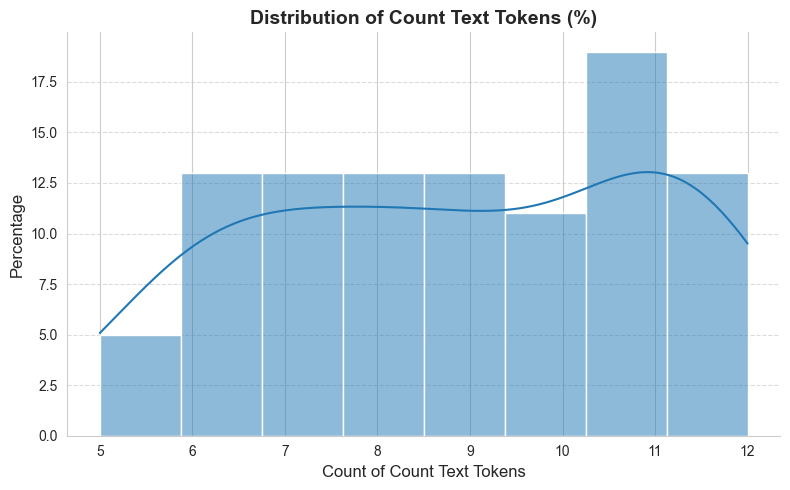

In [6]:
plot_token_count_distribution(t2t_df, column="count_text_tokens")
plt.show()

In [7]:
summary_stats = pd.DataFrame(t2t_df[["n_calls", "runtime_sec"]].describe()).T
summary_stats["sum"] = t2t_df[["n_calls", "runtime_sec"]].sum()
summary_stats

,count,mean,std,min,25%,50%,75%,max,sum
n_calls,100.0,154.780000,93.328526,16.000000,66.000000,157.000000,240.000000,300.000000,15478.000000
runtime_sec,100.0,91.233753,51.997779,9.457057,47.814124,84.335419,132.516525,198.424349,9123.375344


In [8]:
for pt, rmr in t2t_df[["prompt_text", "raw_model_response"]].head(5).itertuples(index=False):
    print(pt)
    print("\t- " + rmr.replace("\n", "\\n"))

['Who developed Recaptcha?']
	- <|im_start|>assistant\nRecaptcha was developed by **Google**. It was created to help verify that users are human and not bots, which is important for tasks like image recognition, spam filtering, and other security measures.<|im_end|><|im_end|>\n
['Who invented fantasy sports?']
	- <|im_start|>assistant\nThe concept of fantasy sports, where fans create teams and compete in leagues, actually has its roots in the world of competitive sports. However, the specific idea of fantasy sports as we know it today was popularized in the United States.\n\nThe idea<|im_end|>\n
['When was the Ateneo de Manila University founded?']
	- <|im_start|>assistant\nThe Ateneo de Manila University was founded in 1909.<|im_end|><|im_end|>\n
['Who discovered infrared light?']
	- <|im_start|>assistant\nThe discovery of infrared light is credited to **William Herschel**, a German-born British astronomer and physicist. In 1800, Herschel was experimenting with a prism to separate whi

In [9]:
def filter_valid_sv(row: pd.Series) -> pd.Series:
    """Filter valid shap values and tokens."""
    sv = np.asarray(row["sv"])
    valid_mask = ~pd.isna(sv)
    tokens = np.asarray(row["raw_prompt_text_tokens"])[valid_mask]
    return pd.Series({"sv": sv[valid_mask], "tokens": tokens, "prompt": "".join(tokens), "row_index": row["row_index"]})

In [10]:
t2t_df = t2t_df.apply(filter_valid_sv, axis=1)
t2t_df.head(5)

,sv,tokens,prompt,row_index
0,"[0.0, 0.1178189367055893, 0.22090736031532288,...","[[', Who, developed, Rec, apt, cha, ']]",['Who developed Recaptcha'],86
1,"[0.14533641934394836, 0.12204218655824661, 0.2...","[[', Who, invented, fantasy, sports, ']]",['Who invented fantasy sports'],25
2,"[0.08296709507703781, 0.08216387033462524, 0.1...","[[', When, was, the, Aten, eo, de, Manila...",['When was the Ateneo de Manila University fou...,55
3,"[0.13821464776992798, 0.2678728699684143, 0.16...","[[', Who, discovered, infrared, light, ']]",['Who discovered infrared light'],49
4,"[0.05872317776083946, 0.278507262468338, 0.098...","[[', How, does, metabolism, work, ']]",['How does metabolism work'],39


In [11]:
def get_stats(prompt: str) -> dict[str, Any]:
    """Get linguistic stats for prompt using spacy."""
    nlp_prompt = nlp(prompt)

    return [
        {
            "text": t.text,
            "dep": t.dep_,
            "pos": t.pos_,
            "children": len(list(t.children)),
        }
        for t in nlp_prompt
    ]

t2t_df["linguistic_stats"] = t2t_df["prompt"].apply(get_stats)

In [12]:
def map_subwords_to_tokens(subwords: list[str], tokens_text: list[str]) -> list[int]:
    """Map subwords to token indices using cosine similarity of embeddings."""
    # Compute embeddings
    token_vecs = np.array([nlp(t.strip()).vector for t in tokens_text])
    subword_vecs = np.array([nlp(s.strip()).vector for s in subwords])

    # Normalize for cosine similarity
    token_vecs_norm = token_vecs / np.linalg.norm(token_vecs, axis=1, keepdims=True)
    subword_vecs_norm = subword_vecs / np.linalg.norm(subword_vecs, axis=1, keepdims=True)

    # Compute cosine similarity matrix (subwords x tokens)
    sim_matrix = np.dot(subword_vecs_norm, token_vecs_norm.T)

    # Map each subword to token with highest similarity
    mapping = np.argmax(sim_matrix, axis=1)

    return mapping.tolist()


t2t_df["stats_mapping"] = t2t_df.apply(
    lambda row: map_subwords_to_tokens(
        row["tokens"],
        [stat["text"] for stat in row["linguistic_stats"]],
    ),
    axis=1,
)

if not (t2t_df["stats_mapping"].apply(len) == t2t_df["tokens"].apply(len)).all().item():
    raise RuntimeError("Subword to token mapping length mismatch.")

In [13]:
t2t_df["stats_matched"] = t2t_df.apply(lambda row: [row["linguistic_stats"][i] for i in row["stats_mapping"]], axis=1)
t2t_df["deps"] = t2t_df["stats_matched"].apply(lambda stats: [stat["dep"] for stat in stats])
t2t_df["pos"] = t2t_df["stats_matched"].apply(lambda stats: [stat["pos"] for stat in stats])
t2t_df["children"] = t2t_df["stats_matched"].apply(lambda stats: [stat["children"] for stat in stats])

t2t_df.drop(columns=["linguistic_stats", "stats_mapping", "stats_matched"], inplace=True)

In [14]:
t2t_exploded_df = (
    t2t_df.apply(
        lambda row: [
            {
                "prompt": row["prompt"],
                "row_index": row["row_index"],
                "token": token,
                "sv": sv,
                "dep": dep,
                "pos": pos,
                "children": children,
            }
            for token, sv, dep, pos, children in zip(
                row["tokens"],
                row["sv"],
                row["deps"],
                row["pos"],
                row["children"],
            )
        ],
        axis=1,
    )
    .explode()
    .apply(pd.Series)
    .reset_index(drop=True)
)

In [15]:
t2t_exploded_df["dep"].unique()

array(['dep', 'nsubj', 'ROOT', 'dobj', 'punct', 'compound', 'advmod',
       'auxpass', 'det', 'nmod', 'amod', 'aux', 'prep', 'pcomp', 'relcl',
       'xcomp', 'attr', 'pobj', 'nsubjpass', 'dative', 'poss', 'case',
       'mark', 'advcl', 'acl', 'agent', 'acomp', 'ccomp', 'conj', 'cc',
       'appos', 'npadvmod', 'oprd'], dtype=object)

In [16]:
ROOT_DEP = "ROOT"
SV_COL = "sv"

data = [
    # --- Core meaning (highest importance) ---
    {"dep": ROOT_DEP, "importance": 1, "group": "core_structure"},
    {"dep": "nsubj", "importance": 1, "group": "core_structure"},
    {"dep": "nsubjpass", "importance": 1, "group": "core_structure"},
    {"dep": "dobj", "importance": 1, "group": "core_structure"},
    {"dep": "agent", "importance": 1, "group": "core_structure"},
    # --- Clause structure (very important) ---
    {"dep": "ccomp", "importance": 2, "group": "clausal_structure"},
    {"dep": "xcomp", "importance": 2, "group": "clausal_structure"},
    {"dep": "advcl", "importance": 2, "group": "clausal_structure"},
    {"dep": "relcl", "importance": 2, "group": "clausal_structure"},
    {"dep": "acl", "importance": 2, "group": "clausal_structure"},
    {"dep": "pcomp", "importance": 2, "group": "clausal_structure"},
    # --- Nominal / verbal complements ---
    {"dep": "attr", "importance": 3, "group": "arguments"},
    {"dep": "acomp", "importance": 3, "group": "arguments"},
    {"dep": "dative", "importance": 3, "group": "arguments"},
    {"dep": "pobj", "importance": 3, "group": "arguments"},
    {"dep": "oprd", "importance": 3, "group": "arguments"},
    # --- Modifiers (less critical, descriptive) ---
    {"dep": "amod", "importance": 4, "group": "modifiers"},
    {"dep": "advmod", "importance": 4, "group": "modifiers"},
    {"dep": "npadvmod", "importance": 4, "group": "modifiers"},
    {"dep": "nmod", "importance": 4, "group": "modifiers"},
    {"dep": "compound", "importance": 4, "group": "modifiers"},
    {"dep": "poss", "importance": 4, "group": "modifiers"},
    {"dep": "appos", "importance": 4, "group": "modifiers"},
    # --- Coordination / structure helpers ---
    {"dep": "conj", "importance": 4, "group": "coordination"},
    {"dep": "cc", "importance": 5, "group": "coordination"},
    # --- Function / grammar glue (lowest importance) ---
    {"dep": "det", "importance": 5, "group": "function_words"},
    {"dep": "case", "importance": 5, "group": "function_words"},
    {"dep": "aux", "importance": 5, "group": "function_words"},
    {"dep": "auxpass", "importance": 5, "group": "function_words"},
    {"dep": "mark", "importance": 5, "group": "function_words"},
    {"dep": "prep", "importance": 5, "group": "function_words"},
    {"dep": "punct", "importance": 6, "group": "punctuation"},
    # --- Generic / unknown ---
    {"dep": "dep", "importance": 4, "group": "generic"},
]

dep_importance_df = pd.DataFrame(data)
t2t_exploded_df = t2t_exploded_df.join(
    dep_importance_df.set_index("dep"),
    on="dep",
    how="left",
)

In [17]:
t2t_exploded_df.head()

,prompt,row_index,token,sv,dep,pos,children,importance,group
0,['Who developed Recaptcha'],86,[',0.000000,dep,X,0,4,generic
1,['Who developed Recaptcha'],86,Who,0.117819,nsubj,PRON,0,1,core_structure
2,['Who developed Recaptcha'],86,developed,0.220907,ROOT,VERB,6,1,core_structure
3,['Who developed Recaptcha'],86,Rec,0.191570,dobj,PROPN,0,1,core_structure
4,['Who developed Recaptcha'],86,apt,0.264331,ROOT,VERB,6,1,core_structure


## Analysis

In [18]:
match_max = t2t_exploded_df.groupby("row_index", group_keys=False)[[SV_COL, "children"]].apply(
    lambda g: int(
        np.intersect1d(
            np.where(g[SV_COL] == g[SV_COL].max())[0],
            np.where(g["children"] == g["children"].max())[0],
        ).size
        > 0
    )
)
match_max.mean()

np.float64(0.11)

In [19]:
match_root = t2t_exploded_df.groupby("row_index", group_keys=False)[[SV_COL, "dep"]].apply(
    lambda g: int(
        np.intersect1d(
            np.where(g[SV_COL] == g[SV_COL].max())[0],
            np.where(g["dep"] == ROOT_DEP)[0],
        ).size
        > 0
    )
)
match_root.mean()

np.float64(0.11)

In [20]:
(match_root == match_max).mean()

np.float64(1.0)

In [21]:
t2t_exploded_df.groupby("importance")[SV_COL].agg(["mean", "std"]).sort_values(by="mean", ascending=False)

,mean,std
importance,,
3,0.167568,0.101598
1,0.150054,0.106961
4,0.114882,0.084040
2,0.104454,0.072481
5,0.065767,0.054125
6,0.050541,0.065793


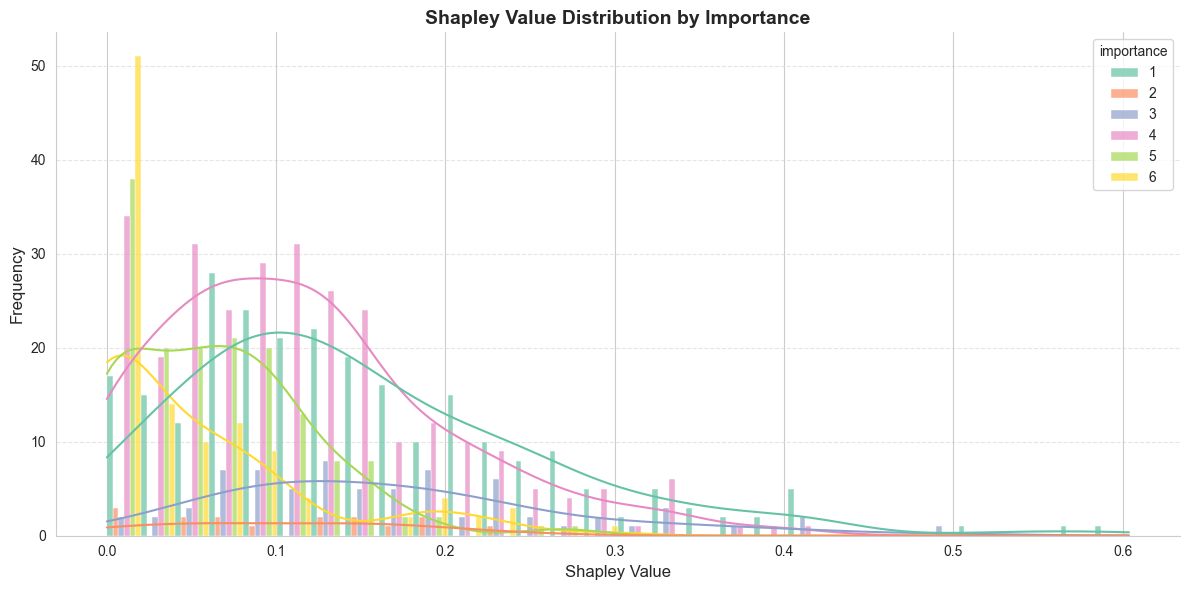

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=t2t_exploded_df,
    x=SV_COL,
    bins=30,
    kde=True,
    hue="importance",
    palette="Set2",
    alpha=0.7,
    ax=ax,
    legend=True,
    multiple="dodge",
)

ax.set_title("Shapley Value Distribution by Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Shapley Value", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [23]:
t2t_exploded_df[["importance", SV_COL]].corr().iloc[0, 1].item()

-0.36059131759323754

In [24]:
t2t_exploded_df.groupby("group")[SV_COL].agg(["mean", "std"]).sort_values(by="mean", ascending=False)

,mean,std
group,,
arguments,0.167568,0.101598
core_structure,0.150054,0.106961
modifiers,0.134476,0.082002
clausal_structure,0.104454,0.072481
generic,0.084515,0.079064
coordination,0.066164,0.048885
function_words,0.065828,0.054498
punctuation,0.050541,0.065793


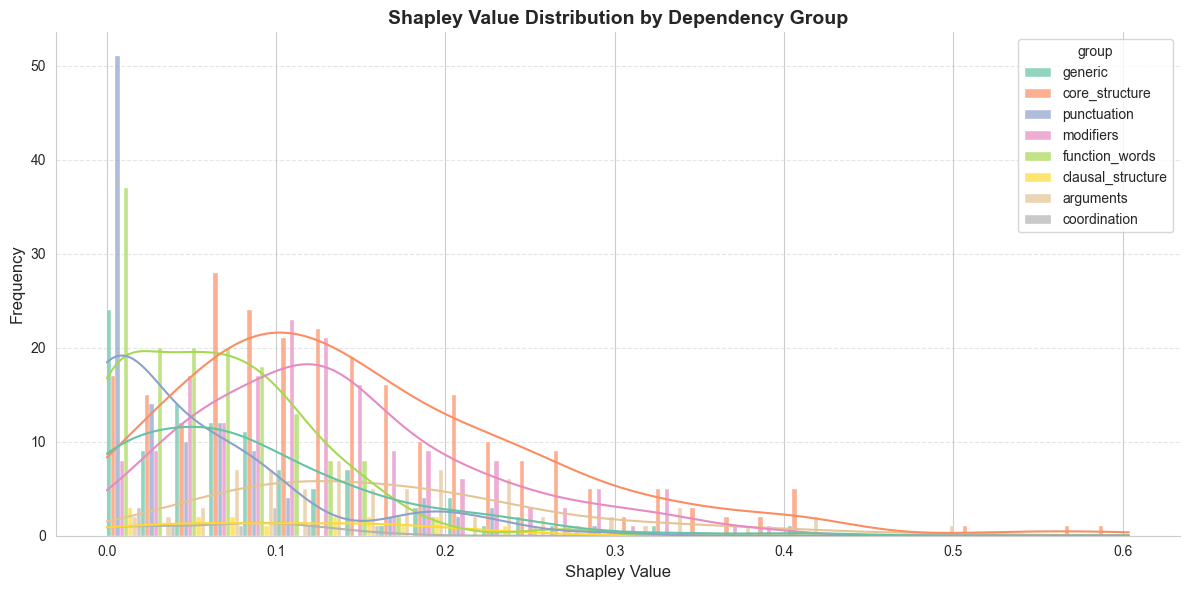

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=t2t_exploded_df,
    x=SV_COL,
    bins=30,
    kde=True,
    hue="group",
    palette="Set2",
    alpha=0.7,
    ax=ax,
    legend=True,
    multiple="dodge",
)

ax.set_title("Shapley Value Distribution by Dependency Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Shapley Value", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

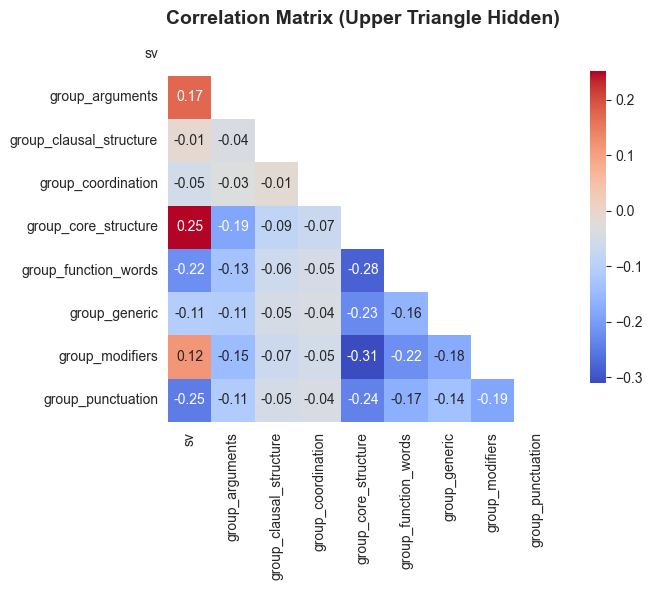

In [26]:
_encoded = OneHotEncoder(sparse_output=False).set_output(transform="pandas").fit_transform(t2t_exploded_df[["group"]])

corr_df = pd.concat([pd.DataFrame(_encoded), t2t_exploded_df[SV_COL]], axis=1).corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
cols = [SV_COL] + [col for col in corr_df.columns if col != SV_COL]
corr_df = corr_df[cols].loc[cols]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix (Upper Triangle Hidden)", fontsize=14, fontweight="bold")
ax.grid(False)
plt.tight_layout()
plt.show()

# Audio

In [27]:
sm2t_df = load_experiments_results("SM2T")
sm2t_df["mode"] = "SM2T"

sm2s_df = load_experiments_results("SM2S")
sm2s_df["mode"] = "SM2S"

# sf2t_df = load_experiments_results("SF2T")
# sf2t_df["mode"] = "SF2T"

# sf2s_df = load_experiments_results("SF2S")
# sf2s_df["mode"] = "SF2S"

# audio_df = pd.concat([sm2t_df, sm2s_df, sf2t_df, sf2s_df], ignore_index=True)
audio_df = pd.concat([sm2t_df, sm2s_df], ignore_index=True)

In [28]:
audio_df["count_audio_segments"] = audio_df["attr_summary"].apply(lambda x: x["count_audio_segments"])
audio_df["sv"] = audio_df["conversation"].apply(lambda x: x[1][1]["shap_values"])
audio_df["prompt_audio_roles"] = audio_df["conversation"].apply(lambda x: x[1][1]["roles"])
audio_df["raw_model_response"] = audio_df["conversation"].apply(lambda x: "".join(x[2][0]["content"]))

if not (
    audio_df[["prompt_audio_roles", "sv"]]
    .apply(lambda x: check_roles(x, target_col="prompt_audio_roles"), axis=1)
    .all()
):
    raise RuntimeError("Prompt audio roles check failed.")

In [29]:
neyman_steps_dist = pd.DataFrame(audio_df.groupby("mode")["neyman_steps"].value_counts(normalize=True))
neyman_steps_dist

,,proportion
mode,neyman_steps,
SM2S,2,1.0
SM2T,2,1.0


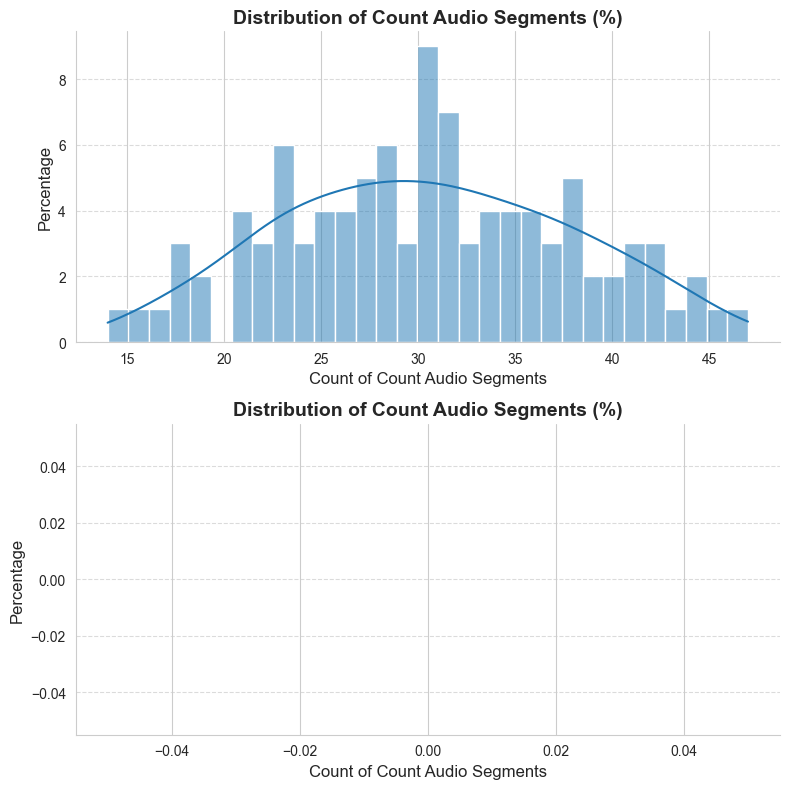

In [30]:
_, axes = plt.subplots(2, 1, figsize=(8, 8))
axes = axes.flatten()

plot_token_count_distribution(
    audio_df[audio_df["mode"].str.startswith("SM")], column="count_audio_segments", plot_ax=axes[0]
)
plot_token_count_distribution(
    audio_df[audio_df["mode"].str.startswith("SF")], column="count_audio_segments", plot_ax=axes[1]
)
plt.show()

In [31]:
summary_stats = audio_df.groupby("mode")[["n_calls", "runtime_sec"]].describe()
sums = audio_df.groupby("mode")[["n_calls", "runtime_sec"]].sum()
sums.columns = pd.MultiIndex.from_product([sums.columns, ["sum"]])
summary_stats = summary_stats.join(sums)
summary_stats

n_calls                                                               \
       count     mean          std    min     25%     50%     75%     max   
mode                                                                        
SM2S   100.0  2365.76  1179.067095  414.0  1451.0  2177.0  3173.5  5552.0   
SM2T   100.0  2366.24  1179.714442  422.0  1445.5  2156.0  3170.5  5558.0   

     runtime_sec                                                    \
           count         mean         std         min          25%   
mode                                                                 
SM2S       100.0  1696.491648  802.612282  328.720241  1070.193724   
SM2T       100.0   768.479234  375.108653  146.074777   448.613671   

                                            n_calls    runtime_sec  
              50%          75%          max     sum            sum  
mode                                                                
SM2S  1568.769281  2260.611348  3742.922515  236576  169649.164784  
SM2T   717.788126  1047.628603  1783.698478  236624   76847.923405

In [32]:
TEXT_SUFFIX = "T"

merged_df = audio_df.merge(t2t_df[["row_index", "prompt"]], on="row_index", how="left")

for mode in merged_df["mode"].unique():
    if TEXT_SUFFIX in mode:
        print(f"Mode: {mode}")
        for pt, rmr in (
            merged_df[merged_df["mode"] == mode][["prompt", "raw_model_response"]].head(5).itertuples(index=False)
        ):
            print(pt)
            print("\t- " + rmr.replace("\n", "\\n"))

Mode: SM2T
['Who developed Recaptcha']
	- <|im_start|>assistant\nRecaptcha was developed by the **ReCAPTCHA Project**, a nonprofit organization founded in 2009 by **Google**.<|im_end|>\n
['Who invented fantasy sports']
	- <|im_start|>assistant\nFantasy sports, also known as fantasy leagues or fantasy leagues, have their roots in the early 2000s. The concept was popularized<|im_end|>\n
['When was the Ateneo de Manila University founded']
	- <|im_start|>assistant\nThe Ateneo de Manila University was founded on October 1, 1900. It was established by the American colonial government as a preparatory school<|im_end|>\n
['Who discovered infrared light']
	- <|im_start|>assistant\nThe discovery of infrared light is credited to **Joseph von Fraunhofer**, a German physicist and instrument maker. In 1814, Fraun<|im_end|>\n
['How does metabolism work']
	- <|im_start|>assistant\nMetabolism is the set of chemical reactions that occur within a living organism to maintain life. It involves the breakdo

# Full

In [33]:
df = pd.concat([t2t_df.assign(mode="T2T"), audio_df], ignore_index=True)
df["sv_mean"] = df[SV_COL].apply(np.mean)
df["audio_in"] = df["mode"].str.startswith("S")
df["audio_out"] = df["mode"].str.endswith("S")

In [34]:
diffs = df.groupby(["row_index", "audio_in"])["sv_mean"].agg(["mean", "std", "min", "max"])
diffs.head(5)

mean           std       min       max
row_index audio_in                                            
0         False     0.083333           NaN  0.083333  0.083333
          True      0.027778  4.161635e-10  0.027778  0.027778
1         False     0.111111           NaN  0.111111  0.111111
          True      0.043478  6.835978e-10  0.043478  0.043478
2         False     0.090909           NaN  0.090909  0.090909

In [35]:
comparison_data = diffs["mean"].unstack(level="audio_in")

false_means = comparison_data[False]
true_means = comparison_data[True]

t_statistic, p_value = stats.ttest_rel(false_means, true_means, nan_policy="omit")

result = {
    "T_Statistic": t_statistic,
    "P_Value": p_value,
    "Degrees_of_Freedom": len(false_means.dropna()) - 1,
}
result

{'T_Statistic': np.float64(34.09565353662808),
 'P_Value': np.float64(1.6225523559221322e-56),
 'Degrees_of_Freedom': 99}

In [36]:
comparison_data.mean()

audio_in
False    0.120039
True     0.035144
dtype: float64